In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

In [2]:
# New One
def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    return value


def weighted_cness(G, W):
    edges = list(G.edges())
    w_closeness = []
    for i in range(0, len(edges)):
        closeness = []
        nd_1 = edges[i][0]
        nd_2 = edges[i][1]
        weight_1 = weight_of_a_node(G,nd_1,W)
        weight_2 = weight_of_a_node(G,nd_2,W)
        edge_w = G.get_edge_data(nd_1, nd_2)
        val = edge_w['weight']
        influence_edge_val = (weight_1 + weight_2) * (val/W)
        closeness.append(edges[i])
        closeness.append(influence_edge_val)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_

def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### lw_1

Name: 
Type: Graph
Number of nodes: 20
Number of edges: 32
Average degree:   3.2000


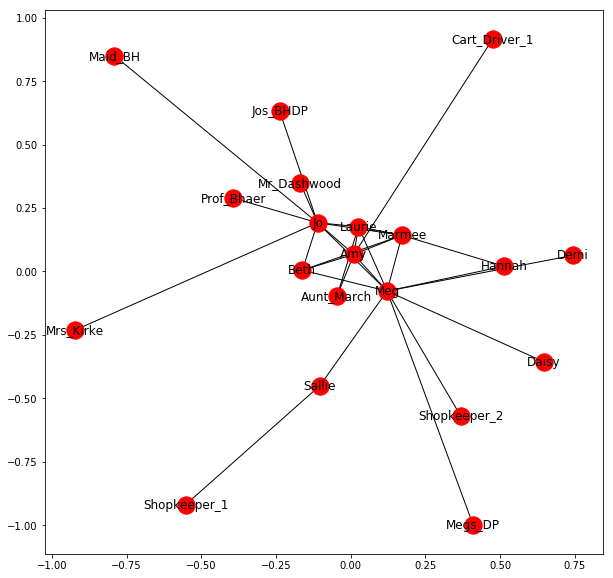

[[('Jo', 'Mr_Dashwood'), 0.18072126180234288], [('Jo', 'Jo'), 0.0059879699519339155], [('Jo', 'Prof_Bhaer'), 0.06325244163082001], [('Jo', 'Maid_BH'), 0.004518031545058572], [('Jo', 'Mrs_Kirke'), 0.004518031545058572], [('Jo', 'Jos_BHDP'), 0.02710818927035143], [('Jo', 'Meg'), 0.17443569695821945], [('Jo', 'Beth'), 0.05364824283743203], [('Jo', 'Amy'), 0.07772637502367233], [('Jo', 'Laurie'), 0.29296864431999564], [('Jo', 'Marmee'), 0.035873711549387226], [('Amy', 'Aunt_March'), 0.14201588976363752], [('Amy', 'Cart_Driver_1'), 0.0038777516254993732], [('Amy', 'Laurie'), 0.23282742201661122], [('Amy', 'Meg'), 0.042042042042042045], [('Amy', 'Beth'), 0.04166328490652816], [('Amy', 'Marmee'), 0.005969933897861826], [('Aunt_March', 'Laurie'), 0.009162315468621776], [('Laurie', 'Meg'), 0.05405405405405406], [('Laurie', 'Marmee'), 0.10745881016151287], [('Sallie', 'Shopkeeper_1'), 0.0018036054072090109], [('Sallie', 'Meg'), 0.03814625436247058], [('Meg', 'Shopkeeper_2'), 0.011389768146524903

In [4]:
lw_1 = nx.read_weighted_edgelist('lw_m_1.txt', delimiter=',')
print(nx.info(lw_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_1)
plt.show()

total_edge_weight = total_weight_of_G(lw_1) #NCF
w_ncf_1 = weighted_cness(lw_1,total_edge_weight)
print(w_ncf_1)

In [5]:
edge_w = list(w_ncf_1)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                     Edges        IF
0        (Jo, Mr_Dashwood)  0.352035
1                 (Jo, Jo)  0.011664
2         (Jo, Prof_Bhaer)  0.123212
3            (Jo, Maid_BH)  0.008801
4          (Jo, Mrs_Kirke)  0.008801
5           (Jo, Jos_BHDP)  0.052805
6                (Jo, Meg)  0.339791
7               (Jo, Beth)  0.104504
8                (Jo, Amy)  0.151407
9             (Jo, Laurie)  0.570686
10            (Jo, Marmee)  0.069880
11       (Amy, Aunt_March)  0.276639
12    (Amy, Cart_Driver_1)  0.007554
13           (Amy, Laurie)  0.453535
14              (Amy, Meg)  0.081896
15             (Amy, Beth)  0.081158
16           (Amy, Marmee)  0.011629
17    (Aunt_March, Laurie)  0.017848
18           (Laurie, Meg)  0.105294
19        (Laurie, Marmee)  0.209324
20  (Sallie, Shopkeeper_1)  0.003513
21           (Sallie, Meg)  0.074307
22     (Meg, Shopkeeper_2)  0.022187
23              (Meg, Meg)  0.023539
24            (Meg, Daisy)  0.022187
25             (Meg, Demi)  0.022187
2

### lw_2

Name: 
Type: Graph
Number of nodes: 29
Number of edges: 51
Average degree:   3.5172


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


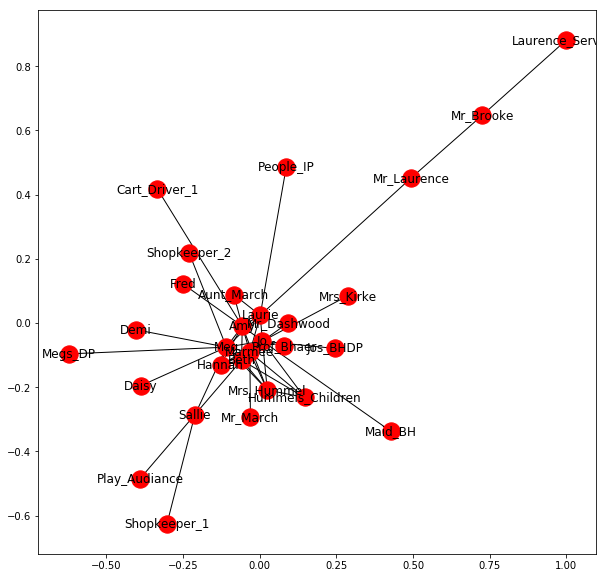

[[('Jo', 'Mr_Dashwood'), 0.07620638527928313], [('Jo', 'Jo'), 0.007604451955014277], [('Jo', 'Prof_Bhaer'), 0.13717149350270963], [('Jo', 'Maid_BH'), 0.0019051596319820785], [('Jo', 'Mrs_Kirke'), 0.005715478895946234], [('Jo', 'Jos_BHDP'), 0.011430957791892469], [('Jo', 'Meg'), 0.14964972256214026], [('Jo', 'Beth'), 0.0984159819746324], [('Jo', 'Amy'), 0.1770972942524717], [('Jo', 'Laurie'), 0.1231749639039424], [('Jo', 'Marmee'), 0.0936085698191636], [('Jo', 'Hannah'), 0.022696812540061766], [('Jo', 'Mrs_Hummel'), 0.005046973434596534], [('Jo', 'Hummels_Children'), 0.00892851361938245], [('Amy', 'Aunt_March'), 0.056450673037701765], [('Amy', 'Cart_Driver_1'), 0.0016914968695167984], [('Amy', 'Laurie'), 0.1856599913239969], [('Amy', 'Meg'), 0.05822634008637156], [('Amy', 'Beth'), 0.05540987639932923], [('Amy', 'Marmee'), 0.08585358273604879], [('Amy', 'Fred'), 0.00845748434758399], [('Amy', 'Hannah'), 0.007551036264397956], [('Amy', 'Mrs_Hummel'), 0.0050372614908481125], [('Aunt_March'

In [6]:
lw_2 = nx.read_weighted_edgelist('lw_m_2.txt', delimiter=',')
print(nx.info(lw_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_2)
plt.show()

total_edge_weight = total_weight_of_G(lw_2) #NCF
w_ncf_2 = weighted_cness(lw_2,total_edge_weight)
print(w_ncf_2)

In [7]:
edge_w = list(w_ncf_2)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                             Edges        IF
0                (Jo, Mr_Dashwood)  0.175491
1                         (Jo, Jo)  0.017512
2                 (Jo, Prof_Bhaer)  0.315885
3                    (Jo, Maid_BH)  0.004387
4                  (Jo, Mrs_Kirke)  0.013162
5                   (Jo, Jos_BHDP)  0.026324
6                        (Jo, Meg)  0.344620
7                       (Jo, Beth)  0.226637
8                        (Jo, Amy)  0.407828
9                     (Jo, Laurie)  0.283653
10                    (Jo, Marmee)  0.215566
11                    (Jo, Hannah)  0.052267
12                (Jo, Mrs_Hummel)  0.011622
13          (Jo, Hummels_Children)  0.020561
14               (Amy, Aunt_March)  0.129997
15            (Amy, Cart_Driver_1)  0.003895
16                   (Amy, Laurie)  0.427546
17                      (Amy, Meg)  0.134086
18                     (Amy, Beth)  0.127600
19                   (Amy, Marmee)  0.197707
20                     (Amy, Fred)  0.019476
21        

### lw_3

Name: 
Type: Graph
Number of nodes: 35
Number of edges: 66
Average degree:   3.7714


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


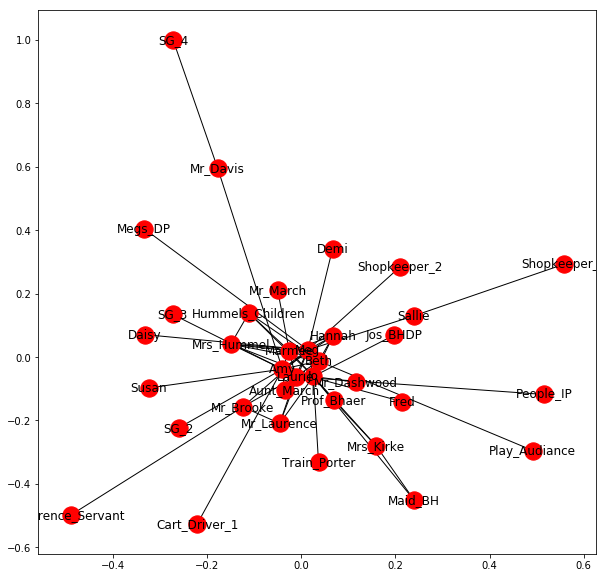

[[('Jo', 'Mr_Dashwood'), 0.05187292185420916], [('Jo', 'Jo'), 0.006932409012131715], [('Jo', 'Prof_Bhaer'), 0.09402004631618152], [('Jo', 'Maid_BH'), 0.0013058339766136321], [('Jo', 'Mrs_Kirke'), 0.003917501929840897], [('Jo', 'Jos_BHDP'), 0.007780938278131374], [('Jo', 'Meg'), 0.1621351699611629], [('Jo', 'Beth'), 0.09617065500452047], [('Jo', 'Amy'), 0.17016465973225522], [('Jo', 'Laurie'), 0.1342448389896945], [('Jo', 'Marmee'), 0.07384532437847108], [('Jo', 'Hannah'), 0.015327592369544256], [('Jo', 'Mrs_Hummel'), 0.0034076334593862354], [('Jo', 'Hummels_Children'), 0.0059592285442241445], [('Jo', 'Train_Porter'), 0.006484115231776145], [('Jo', 'Aunt_March'), 0.07895827638926017], [('Jo', 'Mr_Laurence'), 0.0109910821826876], [('Prof_Bhaer', 'Mrs_Kirke'), 0.007907091301749023], [('Maid_BH', 'Mrs_Kirke'), 0.002635697100583008], [('Amy', 'Aunt_March'), 0.048511844867824665], [('Amy', 'Cart_Driver_1'), 0.0011488936079464389], [('Amy', 'Laurie'), 0.18433660029615925], [('Amy', 'Meg'), 0.

In [8]:
lw_3 = nx.read_weighted_edgelist('lw_m_3.txt', delimiter=',')
print(nx.info(lw_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_3)
plt.show()

total_edge_weight = total_weight_of_G(lw_3) #NCF
w_ncf_3 = weighted_cness(lw_3,total_edge_weight)
print(w_ncf_3)

In [9]:
edge_w = list(w_ncf_3)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                             Edges        IF
0                (Jo, Mr_Dashwood)  0.123323
1                         (Jo, Jo)  0.016481
2                 (Jo, Prof_Bhaer)  0.223525
3                    (Jo, Maid_BH)  0.003105
4                  (Jo, Mrs_Kirke)  0.009314
5                   (Jo, Jos_BHDP)  0.018499
6                        (Jo, Meg)  0.385462
7                       (Jo, Beth)  0.228637
8                        (Jo, Amy)  0.404552
9                     (Jo, Laurie)  0.319156
10                    (Jo, Marmee)  0.175561
11                    (Jo, Hannah)  0.036440
12                (Jo, Mrs_Hummel)  0.008101
13          (Jo, Hummels_Children)  0.014168
14              (Jo, Train_Porter)  0.015415
15                (Jo, Aunt_March)  0.187716
16               (Jo, Mr_Laurence)  0.026130
17         (Prof_Bhaer, Mrs_Kirke)  0.018798
18            (Maid_BH, Mrs_Kirke)  0.006266
19               (Amy, Aunt_March)  0.115333
20            (Amy, Cart_Driver_1)  0.002731
21        

### lw_4

Name: 
Type: Graph
Number of nodes: 35
Number of edges: 68
Average degree:   3.8857


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


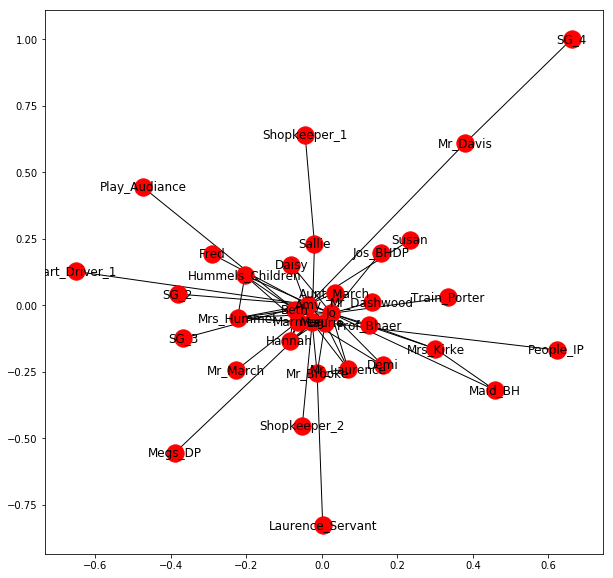

[[('Jo', 'Mr_Dashwood'), 0.044138502147921956], [('Jo', 'Jo'), 0.0057553956834532375], [('Jo', 'Prof_Bhaer'), 0.07989648568914652], [('Jo', 'Maid_BH'), 0.0011096734123492572], [('Jo', 'Mrs_Kirke'), 0.003329020237047772], [('Jo', 'Jos_BHDP'), 0.006620775322188293], [('Jo', 'Meg'), 0.179144454220796], [('Jo', 'Beth'), 0.08567879509342166], [('Jo', 'Amy'), 0.22864240981315667], [('Jo', 'Laurie'), 0.13876507427151805], [('Jo', 'Marmee'), 0.1256622328036851], [('Jo', 'Hannah'), 0.01701775270431137], [('Jo', 'Mrs_Hummel'), 0.002837327260493763], [('Jo', 'Hummels_Children'), 0.004995600641788727], [('Jo', 'Train_Porter'), 0.0055173127684902444], [('Jo', 'Aunt_March'), 0.06611976605765747], [('Jo', 'Mr_Laurence'), 0.009242275244552558], [('Jo', 'Demi'), 0.0036659593188758345], [('Jo', 'Daisy'), 0.0036659593188758345], [('Prof_Bhaer', 'Mrs_Kirke'), 0.007024481134516846], [('Maid_BH', 'Mrs_Kirke'), 0.0023414937115056158], [('Amy', 'Aunt_March'), 0.040689405310284144], [('Amy', 'Cart_Driver_1'), 

In [10]:
lw_4 = nx.read_weighted_edgelist('lw_m_4.txt', delimiter=',')
print(nx.info(lw_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_4)
plt.show()

total_edge_weight = total_weight_of_G(lw_4) #NCF
w_ncf_4 = weighted_cness(lw_4,total_edge_weight)
print(w_ncf_4)

In [11]:
edge_w = list(w_ncf_4)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                             Edges        IF
0                (Jo, Mr_Dashwood)  0.097937
1                         (Jo, Jo)  0.012770
2                 (Jo, Prof_Bhaer)  0.177279
3                    (Jo, Maid_BH)  0.002462
4                  (Jo, Mrs_Kirke)  0.007387
5                   (Jo, Jos_BHDP)  0.014691
6                        (Jo, Meg)  0.397495
7                       (Jo, Beth)  0.190109
8                        (Jo, Amy)  0.507324
9                     (Jo, Laurie)  0.307900
10                    (Jo, Marmee)  0.278826
11                    (Jo, Hannah)  0.037760
12                (Jo, Mrs_Hummel)  0.006296
13          (Jo, Hummels_Children)  0.011085
14              (Jo, Train_Porter)  0.012242
15                (Jo, Aunt_March)  0.146710
16               (Jo, Mr_Laurence)  0.020507
17                      (Jo, Demi)  0.008134
18                     (Jo, Daisy)  0.008134
19         (Prof_Bhaer, Mrs_Kirke)  0.015586
20            (Maid_BH, Mrs_Kirke)  0.005195
21        

### lw_5

Name: 
Type: Graph
Number of nodes: 38
Number of edges: 79
Average degree:   4.1579


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


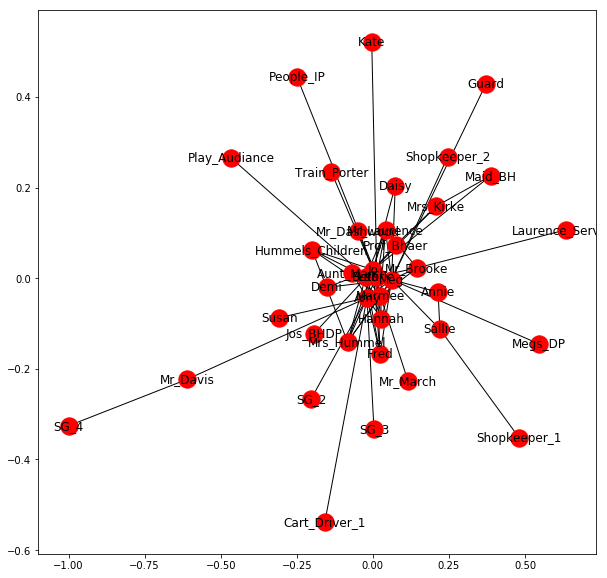

[[('Jo', 'Mr_Dashwood'), 0.035231226231352664], [('Jo', 'Jo'), 0.004759056769154493], [('Jo', 'Prof_Bhaer'), 0.06372305983199819], [('Jo', 'Maid_BH'), 0.0008850424976666415], [('Jo', 'Mrs_Kirke'), 0.0026551274929999245], [('Jo', 'Jos_BHDP'), 0.005284683934702899], [('Jo', 'Meg'), 0.1578607542607764], [('Jo', 'Beth'), 0.09827878412492311], [('Jo', 'Amy'), 0.19519768553573486], [('Jo', 'Laurie'), 0.14564205358271737], [('Jo', 'Marmee'), 0.10423044631428811], [('Jo', 'Hannah'), 0.014098172948384832], [('Jo', 'Mrs_Hummel'), 0.002350405798377943], [('Jo', 'Hummels_Children'), 0.003976298476675649], [('Jo', 'Train_Porter'), 0.004403903278919083], [('Jo', 'Aunt_March'), 0.05378799609615284], [('Jo', 'Mr_Laurence'), 0.008126977317056886], [('Jo', 'Demi'), 0.0030056639878622738], [('Jo', 'Daisy'), 0.0030056639878622738], [('Jo', 'Fred'), 0.0011709410573061464], [('Prof_Bhaer', 'Mrs_Kirke'), 0.005222887227401939], [('Maid_BH', 'Mrs_Kirke'), 0.0017409624091339795], [('Amy', 'Aunt_March'), 0.03313

In [12]:
lw_5 = nx.read_weighted_edgelist('lw_m_5.txt', delimiter=',')
print(nx.info(lw_5))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_5)
plt.show()

total_edge_weight = total_weight_of_G(lw_5) #NCF
w_ncf_5 = weighted_cness(lw_5,total_edge_weight)
print(w_ncf_5)

In [13]:
edge_w = list(w_ncf_5)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                             Edges        IF
0                (Jo, Mr_Dashwood)  0.078517
1                         (Jo, Jo)  0.010606
2                 (Jo, Prof_Bhaer)  0.142015
3                    (Jo, Maid_BH)  0.001972
4                  (Jo, Mrs_Kirke)  0.005917
5                   (Jo, Jos_BHDP)  0.011778
6                        (Jo, Meg)  0.351814
7                       (Jo, Beth)  0.219027
8                        (Jo, Amy)  0.435024
9                     (Jo, Laurie)  0.324583
10                    (Jo, Marmee)  0.232291
11                    (Jo, Hannah)  0.031420
12                (Jo, Mrs_Hummel)  0.005238
13          (Jo, Hummels_Children)  0.008862
14              (Jo, Train_Porter)  0.009815
15                (Jo, Aunt_March)  0.119874
16               (Jo, Mr_Laurence)  0.018112
17                      (Jo, Demi)  0.006699
18                     (Jo, Daisy)  0.006699
19                      (Jo, Fred)  0.002610
20         (Prof_Bhaer, Mrs_Kirke)  0.011640
21        

### lw_6

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 90
Average degree:   4.1860


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


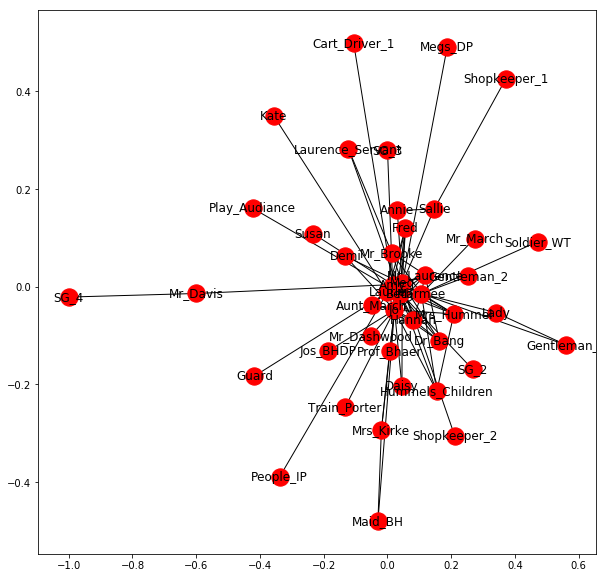

[[('Jo', 'Mr_Dashwood'), 0.02917569613256198], [('Jo', 'Jo'), 0.004001984912155075], [('Jo', 'Prof_Bhaer'), 0.05273333710215388], [('Jo', 'Maid_BH'), 0.0007324074597521372], [('Jo', 'Mrs_Kirke'), 0.002197222379256412], [('Jo', 'Jos_BHDP'), 0.004376354419884297], [('Jo', 'Meg'), 0.14677746999076638], [('Jo', 'Beth'), 0.12558765334388602], [('Jo', 'Amy'), 0.18819153146022952], [('Jo', 'Laurie'), 0.12446529858480787], [('Jo', 'Marmee'), 0.10368578086821062], [('Jo', 'Hannah'), 0.015839096488087387], [('Jo', 'Mrs_Hummel'), 0.0019763694951664876], [('Jo', 'Hummels_Children'), 0.0033557578155916103], [('Jo', 'Train_Porter'), 0.0036469620165702475], [('Jo', 'Aunt_March'), 0.04469821169465015], [('Jo', 'Mr_Laurence'), 0.00685045948203843], [('Jo', 'Demi'), 0.0024813914485461775], [('Jo', 'Daisy'), 0.0024813914485461775], [('Jo', 'Fred'), 0.0009768782859404148], [('Jo', 'Dr_Bang'), 0.003825101601120596], [('Prof_Bhaer', 'Mrs_Kirke'), 0.004178868223189553], [('Maid_BH', 'Mrs_Kirke'), 0.001392956

In [14]:
lw_6 = nx.read_weighted_edgelist('lw_m_6.txt', delimiter=',')
print(nx.info(lw_6))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_6)
plt.show()

total_edge_weight = total_weight_of_G(lw_6) #NCF
w_ncf_6 = weighted_cness(lw_6,total_edge_weight)
print(w_ncf_6)

In [15]:
edge_w = list(w_ncf_6)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                             Edges        IF
0                (Jo, Mr_Dashwood)  0.065086
1                         (Jo, Jo)  0.008928
2                 (Jo, Prof_Bhaer)  0.117639
3                    (Jo, Maid_BH)  0.001634
4                  (Jo, Mrs_Kirke)  0.004902
5                   (Jo, Jos_BHDP)  0.009763
6                        (Jo, Meg)  0.327436
7                       (Jo, Beth)  0.280165
8                        (Jo, Amy)  0.419823
9                     (Jo, Laurie)  0.277661
10                    (Jo, Marmee)  0.231305
11                    (Jo, Hannah)  0.035334
12                (Jo, Mrs_Hummel)  0.004409
13          (Jo, Hummels_Children)  0.007486
14              (Jo, Train_Porter)  0.008136
15                (Jo, Aunt_March)  0.099714
16               (Jo, Mr_Laurence)  0.015282
17                      (Jo, Demi)  0.005536
18                     (Jo, Daisy)  0.005536
19                      (Jo, Fred)  0.002179
20                   (Jo, Dr_Bang)  0.008533
21        

### lw_7

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 98
Average degree:   4.5581


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


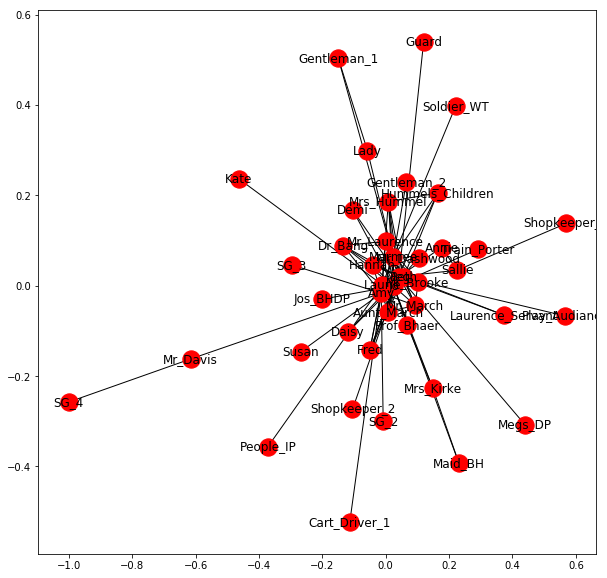

[[('Jo', 'Mr_Dashwood'), 0.025452971971048916], [('Jo', 'Jo'), 0.0034438123970180158], [('Jo', 'Prof_Bhaer'), 0.04597601120615066], [('Jo', 'Maid_BH'), 0.000638555711196537], [('Jo', 'Mrs_Kirke'), 0.001915667133589611], [('Jo', 'Jos_BHDP'), 0.0038179457956573383], [('Jo', 'Meg'), 0.15814165040060352], [('Jo', 'Beth'), 0.13988070499972016], [('Jo', 'Amy'), 0.17748594628879938], [('Jo', 'Laurie'), 0.17748594628879938], [('Jo', 'Marmee'), 0.09785187552961168], [('Jo', 'Hannah'), 0.0187241493253419], [('Jo', 'Mrs_Hummel'), 0.0016995920793058672], [('Jo', 'Hummels_Children'), 0.0029000916924348257], [('Jo', 'Train_Porter'), 0.0031816214963811145], [('Jo', 'Aunt_March'), 0.042415421585302884], [('Jo', 'Mr_Laurence'), 0.005856154633870863], [('Jo', 'Demi'), 0.002152754650122979], [('Jo', 'Daisy'), 0.002152754650122979], [('Jo', 'Fred'), 0.0008393827840248014], [('Jo', 'Dr_Bang'), 0.0032876135625960323], [('Jo', 'Mr_March'), 0.004276872847268594], [('Prof_Bhaer', 'Mrs_Kirke'), 0.00374542490824

In [16]:
lw_7 = nx.read_weighted_edgelist('lw_m_7.txt', delimiter=',')
print(nx.info(lw_7))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_7)
plt.show()

total_edge_weight = total_weight_of_G(lw_7) #NCF
w_ncf_7 = weighted_cness(lw_7,total_edge_weight)
print(w_ncf_7)

In [17]:
edge_w = list(w_ncf_7)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                             Edges        IF
0                (Jo, Mr_Dashwood)  0.056981
1                         (Jo, Jo)  0.007710
2                 (Jo, Prof_Bhaer)  0.102925
3                    (Jo, Maid_BH)  0.001430
4                  (Jo, Mrs_Kirke)  0.004289
5                   (Jo, Jos_BHDP)  0.008547
6                        (Jo, Meg)  0.354028
7                       (Jo, Beth)  0.313147
8                        (Jo, Amy)  0.397333
9                     (Jo, Laurie)  0.397333
10                    (Jo, Marmee)  0.219058
11                    (Jo, Hannah)  0.041917
12                (Jo, Mrs_Hummel)  0.003805
13          (Jo, Hummels_Children)  0.006492
14              (Jo, Train_Porter)  0.007123
15                (Jo, Aunt_March)  0.094954
16               (Jo, Mr_Laurence)  0.013110
17                      (Jo, Demi)  0.004819
18                     (Jo, Daisy)  0.004819
19                      (Jo, Fred)  0.001879
20                   (Jo, Dr_Bang)  0.007360
21        

### lw_8

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 98
Average degree:   4.5581


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


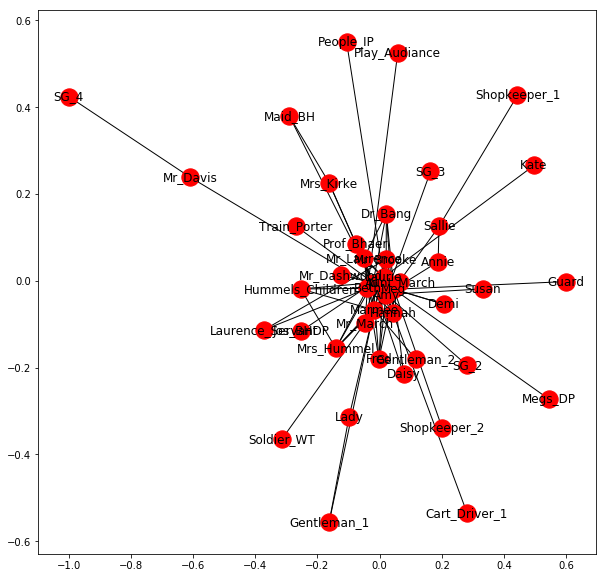

[[('Jo', 'Mr_Dashwood'), 0.024489791841763184], [('Jo', 'Jo'), 0.008166593173986554], [('Jo', 'Prof_Bhaer'), 0.04422544791000301], [('Jo', 'Maid_BH'), 0.0006142423320833751], [('Jo', 'Mrs_Kirke'), 0.0018427269962501252], [('Jo', 'Jos_BHDP'), 0.0036734687762644772], [('Jo', 'Meg'), 0.1498365099982505], [('Jo', 'Beth'), 0.13254567158077177], [('Jo', 'Amy'), 0.1811870058283108], [('Jo', 'Laurie'), 0.20556193934781447], [('Jo', 'Marmee'), 0.1276928242346399], [('Jo', 'Hannah'), 0.017750438167853284], [('Jo', 'Mrs_Hummel'), 0.00161134573836506], [('Jo', 'Hummels_Children'), 0.002766587414424308], [('Jo', 'Train_Porter'), 0.003061223980220398], [('Jo', 'Aunt_March'), 0.040217058924483316], [('Jo', 'Mr_Laurence'), 0.011113957599967106], [('Jo', 'Demi'), 0.0020569627364645706], [('Jo', 'Daisy'), 0.0020569627364645706], [('Jo', 'Fred'), 0.0007963510343324842], [('Jo', 'Dr_Bang'), 0.0031228146747653437], [('Jo', 'Mr_March'), 0.004053333546403845], [('Prof_Bhaer', 'Mrs_Kirke'), 0.0037064281209128

In [18]:
lw_8 = nx.read_weighted_edgelist('lw_m_8.txt', delimiter=',')
print(nx.info(lw_8))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_8)
plt.show()

total_edge_weight = total_weight_of_G(lw_8) #NCF
w_ncf_8 = weighted_cness(lw_8,total_edge_weight)
print(w_ncf_8)

In [19]:
edge_w = list(w_ncf_8)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                             Edges        IF
0                (Jo, Mr_Dashwood)  0.053576
1                         (Jo, Jo)  0.017866
2                 (Jo, Prof_Bhaer)  0.096751
3                    (Jo, Maid_BH)  0.001344
4                  (Jo, Mrs_Kirke)  0.004031
5                   (Jo, Jos_BHDP)  0.008036
6                        (Jo, Meg)  0.327794
7                       (Jo, Beth)  0.289967
8                        (Jo, Amy)  0.396378
9                     (Jo, Laurie)  0.449703
10                    (Jo, Marmee)  0.279350
11                    (Jo, Hannah)  0.038832
12                (Jo, Mrs_Hummel)  0.003525
13          (Jo, Hummels_Children)  0.006052
14              (Jo, Train_Porter)  0.006697
15                (Jo, Aunt_March)  0.087982
16               (Jo, Mr_Laurence)  0.024314
17                      (Jo, Demi)  0.004500
18                     (Jo, Daisy)  0.004500
19                      (Jo, Fred)  0.001742
20                   (Jo, Dr_Bang)  0.006832
21        

### lw_9

Name: 
Type: Graph
Number of nodes: 48
Number of edges: 113
Average degree:   4.7083


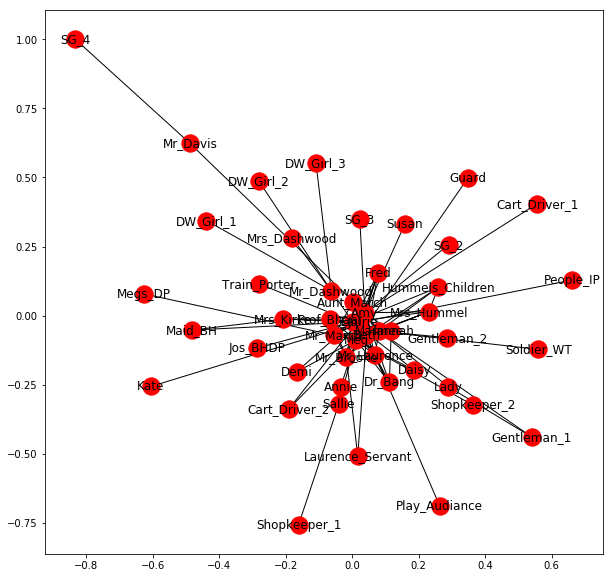

[[('Jo', 'Mr_Dashwood'), 0.0648579472272195], [('Jo', 'Jo'), 0.007243743730117009], [('Jo', 'Prof_Bhaer'), 0.07579856580680698], [('Jo', 'Maid_BH'), 0.0005540796387709667], [('Jo', 'Mrs_Kirke'), 0.006714926876671532], [('Jo', 'Jos_BHDP'), 0.003315053373851525], [('Jo', 'Meg'), 0.15878642291525735], [('Jo', 'Beth'), 0.1172835934833009], [('Jo', 'Amy'), 0.19394122488643525], [('Jo', 'Laurie'), 0.1851213713215814], [('Jo', 'Marmee'), 0.12040217307076091], [('Jo', 'Hannah'), 0.017791938317964485], [('Jo', 'Mrs_Hummel'), 0.0014215225317866051], [('Jo', 'Hummels_Children'), 0.0024639723884301154], [('Jo', 'Train_Porter'), 0.002762544478209604], [('Jo', 'Aunt_March'), 0.035629689977192805], [('Jo', 'Mr_Laurence'), 0.012196427711259715], [('Jo', 'Demi'), 0.001838554832548311], [('Jo', 'Daisy'), 0.001838554832548311], [('Jo', 'Fred'), 0.0007040856075948572], [('Jo', 'Dr_Bang'), 0.002760842839819804], [('Jo', 'Mr_March'), 0.00719662143624563], [('Jo', 'Mr_Brooke'), 0.001392725574420762], [('Mr_D

In [21]:
lw_9 = nx.read_weighted_edgelist('lw_m_9.txt', delimiter=',')
print(nx.info(lw_9))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_9)
plt.show()

total_edge_weight = total_weight_of_G(lw_9) #NCF
w_ncf_9 = weighted_cness(lw_9,total_edge_weight)
print(w_ncf_9)

In [22]:
edge_w = list(w_ncf_9)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()
df_2.to_csv('lw_mb_t9.csv')
print(df_2)

                              Edges        IF
0                 (Jo, Mr_Dashwood)  0.145890
1                          (Jo, Jo)  0.016294
2                  (Jo, Prof_Bhaer)  0.170500
3                     (Jo, Maid_BH)  0.001246
4                   (Jo, Mrs_Kirke)  0.015104
5                    (Jo, Jos_BHDP)  0.007457
6                         (Jo, Meg)  0.357172
7                        (Jo, Beth)  0.263816
8                         (Jo, Amy)  0.436248
9                      (Jo, Laurie)  0.416409
10                     (Jo, Marmee)  0.270831
11                     (Jo, Hannah)  0.040021
12                 (Jo, Mrs_Hummel)  0.003198
13           (Jo, Hummels_Children)  0.005542
14               (Jo, Train_Porter)  0.006214
15                 (Jo, Aunt_March)  0.080145
16                (Jo, Mr_Laurence)  0.027434
17                       (Jo, Demi)  0.004136
18                      (Jo, Daisy)  0.004136
19                       (Jo, Fred)  0.001584
20                    (Jo, Dr_Bang